In [1]:
# Standard library imports
import os
import random
import sys
from itertools import product

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Configure matplotlib
plt.style.use('../fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('../src/')
if project_root not in sys.path:
    sys.path.append(project_root)
    
# Project imports
from gaugefixer import get_alphabet
from gaugefixer.features import get_additive_features
from gaugefixer.fixers.fix_additive_model import fix_additive_model
from gaugefixer._test_gauge_fixing import _test_gauge_fixing
from gaugefixer.seq_embedder import SeqEmbedder
from gaugefixer.evaluate_model_on_seqs import evaluate_model_on_seqs


In [2]:
# Plot parameters
def plot_additive_thetas(theta_series, fixed_theta_series):
    for order in range(2)[::-1]:
        ix = [len(orbit)==order for orbit,_ in theta_series.index]
        plt.scatter(theta_series[ix], fixed_theta_series[ix], marker='.', label=f'{order=}')
    plt.xlabel('theta_series')
    plt.ylabel('fixed_theta_series')
    plt.legend()
    print(f'features match: {all(theta_series.index == fixed_theta_series.index)}')

N=81
000 f=-5.878333 	 f_fixed=-5.878333
001 f=-6.951696 	 f_fixed=-6.951696
002 f=-4.970052 	 f_fixed=-4.970052
003 f=-6.093311 	 f_fixed=-6.093311
004 f=-6.179394 	 f_fixed=-6.179394
005 f=0.887613 	 f_fixed=0.887613
006 f=-13.741566 	 f_fixed=-13.741566
007 f=-6.935326 	 f_fixed=-6.935326
008 f=2.551487 	 f_fixed=2.551487
009 f=-5.293400 	 f_fixed=-5.293400
Tested 10 random sequences; all seqs passed.
features match: True


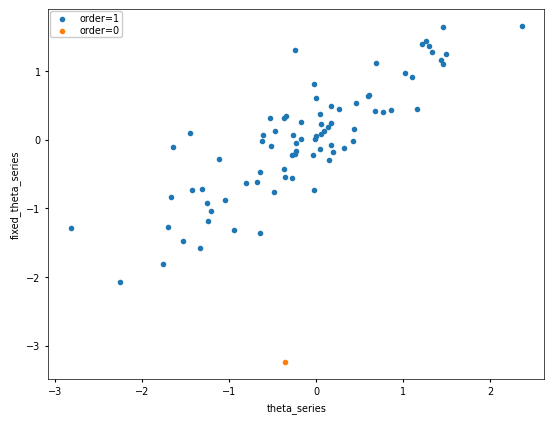

In [3]:
L = 20
alphabet = get_alphabet('dna')
alpha = len(alphabet)
features = get_additive_features(L=L, alphabet=alphabet)
N = len(features)
print(f'{N=:,}')

# Create theta_series
theta_series = pd.Series(index=features,
                         data=np.random.normal(size=N))



# Fix gauge
fixed_theta_series = fix_additive_model(theta=theta_series,
                                        L=L, 
                                        alphabet=alphabet,
                                        gauge='zero-sum')

# Create embedder
embedder = SeqEmbedder(features=features, 
                       L=L)

# Test result
_test_gauge_fixing(theta_series=theta_series, 
                   theta_fixed_series=fixed_theta_series, 
                   L=L, 
                   alphabet=alphabet, 
                   embedder=embedder,
                   num_trials=10)

# Plot resulting parameters
plot_additive_thetas(theta_series=theta_series, fixed_theta_series=fixed_theta_series)

In [4]:
random_seqs = [''.join(random.choices(alphabet, k=L)) for _ in range(100)]
evaluate_model_on_seqs(theta=theta_series,
                       seqs=random_seqs,
                       embedder=embedder)

array([ -0.82980522,  -7.74629999,  -3.00068975,  -2.05558881,
        -8.14788848,   0.70840226,  -0.92506969,  -3.80853801,
        -8.852003  ,   1.42773325,   4.5494543 ,  -5.54167791,
       -10.38403377,  -2.51704839,  -2.23258749,  -9.81125826,
         1.53006391,  -2.83036   ,   3.43259979,  -3.7071123 ,
        -3.22132565,  -8.16639477,  -5.27643299,   1.12260382,
       -11.39615383,  -2.04249825,  -8.71771424,  -6.21512452,
        -3.75269762,   0.91750279,  -5.41886801,  -5.30608313,
        -0.23298635,  -5.37645861,  -7.31937572,  -8.74773449,
        -4.89967563,  -3.68037904,   0.39055404,  -3.44158775,
        -4.91392826,  -3.81185345,  -1.54282438,   0.57770431,
        -3.8783273 ,  -7.90980571,  -7.87503276,  -5.4474665 ,
         1.93095603,  -3.97577516,  -6.16494981,  -3.68182055,
        -4.50624059,  -2.18105674,  -4.95033476,  -4.09723424,
         2.92240759,  -8.51031367,   5.6110954 ,  -5.52614868,
        -0.08099727,   0.59060245,  -7.86709868,  -1.03